### 每月销售额总量预测

### Connect postgresql database

In [ ]:
import pandas as pd
from sqlalchemy import create_engine, text

# 数据库配置
username = "XXXXXX"
password = "YYYYYY"
host = "localhost"
port = 5432
database = "eyewear-data"

# 创建连接
engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)


### Query and cal customer RFM feature

In [ ]:
# 1 . 每月销售额、订单数量和平均订单价值
sale_amount_monthly_sql = """
WITH region_monthly_quantity AS (
    SELECT
        TO_CHAR(o.order_date,'YYYY-MM') AS order_month,
        c.region,
        SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END) AS region_paid_quantity
    FROM "Order" o
    JOIN "OrderItem" oi ON o.order_id = oi.order_id
    LEFT JOIN "CustomerInfo" c ON o.customer_id = c.customer_id
    WHERE o.order_status IN ('Completed','Shipped')
      AND o.order_date IS NOT NULL
    GROUP BY TO_CHAR(o.order_date,'YYYY-MM'), c.region
),

-- 地区集中度（基于销量）
region_rank AS (
    SELECT *,
           RANK() OVER(PARTITION BY order_month ORDER BY region_paid_quantity DESC) AS region_rank
    FROM region_monthly_quantity
),

region_concentration AS (
    SELECT
        order_month,
        MAX(CASE WHEN region_rank = 1 THEN region_paid_quantity END)::numeric 
            / NULLIF(SUM(region_paid_quantity)::numeric, 0) AS top_region_quantity_ratio,
        SUM(CASE WHEN region_rank <=5 THEN region_paid_quantity ELSE 0 END)::numeric 
            / NULLIF(SUM(region_paid_quantity)::numeric, 0) AS top5_region_quantity_ratio
    FROM region_rank
    GROUP BY order_month
),

region_entropy AS (
    SELECT
        order_month,
        -SUM(qty_share * LN(qty_share)) AS region_paid_qty_entropy
    FROM (
        SELECT
            order_month,
            region,
            region_paid_quantity::numeric / SUM(region_paid_quantity::numeric) OVER (PARTITION BY order_month) AS qty_share
        FROM region_monthly_quantity
    ) t
    GROUP BY order_month
)

SELECT
    to_char(o.order_date, 'YYYY-MM') AS order_month,
    -- 基础指标
    COUNT(DISTINCT o.order_id) AS order_count,
    COUNT(DISTINCT o.customer_id) AS unique_customer_count,
    SUM(oi.line_price_after_tax) AS monthly_revenue,
    SUM(oi.line_price_before_tax) AS monthly_revenue_before_tax,
    SUM(o.total_price_after_tax)/COUNT(DISTINCT o.order_id) AS avg_order_value,

    -- 目标变量
    SUM(oi.quantity) AS total_quantity,   
    SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END) AS customer_paid_quantity, -- ← 预测目标
    
    -- 每个订单平均付费商品数量（推荐）
    SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END)::numeric 
        / NULLIF(COUNT(DISTINCT o.order_id), 0) AS avg_paid_qty_per_order,

    -- 每个订单平均总商品数量（包含赠品）
    SUM(oi.quantity)::numeric 
        / NULLIF(COUNT(DISTINCT o.order_id), 0) AS avg_total_qty_per_order,

    -- 价格
    SUM(oi.line_price_after_tax)/NULLIF(SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END),0) 
        AS avg_unit_price,

    -- 促销
    COUNT(DISTINCT pa.campaign_id) AS promotion_count,
    COUNT(DISTINCT CASE WHEN o.campaign_id IS NOT NULL THEN o.order_id END) AS promo_order_count,
    -- 促销订单占比（按订单）
    COUNT(DISTINCT CASE WHEN o.campaign_id IS NOT NULL THEN o.order_id END)::numeric 
        / NULLIF(COUNT(DISTINCT o.order_id), 0) AS promo_order_ratio,
    
    -- 促销贡献的付费销量占比（推荐使用这个）
    SUM(CASE WHEN o.campaign_id IS NOT NULL 
             THEN (CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END)
             ELSE 0 END)::numeric 
        / NULLIF(SUM(CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END), 0) 
        AS promo_paid_qty_ratio,

    -- 促销贡献的总销量占比（作为对比）
    SUM(CASE WHEN o.campaign_id IS NOT NULL THEN oi.quantity ELSE 0 END)::numeric 
        / NULLIF(SUM(oi.quantity), 0) AS promo_total_qty_ratio,
    
        
    AVG(CASE WHEN pa.discount_type='Percentage' THEN pa.discount_value END) AS avg_percentage_discount,

    COUNT(DISTINCT CASE WHEN pa.discount_type = 'Percentage' THEN o.order_id END)::numeric 
        / NULLIF(COUNT(DISTINCT o.order_id), 0) AS percentage_discount_order_ratio,

    COUNT(DISTINCT CASE WHEN pa.discount_type = 'Fixed Amount' THEN o.order_id END)::numeric 
        / NULLIF(COUNT(DISTINCT o.order_id), 0) AS fixed_amount_discount_order_ratio,

    COUNT(DISTINCT CASE WHEN pa.discount_type = 'Free Gift' THEN o.order_id END)::numeric 
        / NULLIF(COUNT(DISTINCT o.order_id), 0) AS free_gift_order_ratio,

    COUNT(DISTINCT CASE WHEN pa.discount_type = 'Buy One Get One' THEN o.order_id END)::numeric 
        / NULLIF(COUNT(DISTINCT o.order_id), 0) AS bogo_order_ratio,

    -- 地区
    MAX(rc.top_region_quantity_ratio) AS top_region_quantity_ratio,
    MAX(rc.top5_region_quantity_ratio) AS top5_region_quantity_ratio,
    MAX(re.region_paid_qty_entropy) AS region_paid_qty_entropy,

    -- 产品结构（已使用quantity）
    SUM(CASE WHEN p.category = 'Eyeglasses' 
            THEN (CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END) 
            ELSE 0 END) AS paid_qty_eyeglasses,

    SUM(CASE WHEN p.category = 'Sunglasses' 
            THEN (CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END) 
            ELSE 0 END) AS paid_qty_sunglass,

    SUM(CASE WHEN p.category = 'AI Glasses' 
            THEN (CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END) 
            ELSE 0 END) AS paid_qty_ai_glasses,

    SUM(CASE WHEN p.category = 'Lens' 
            THEN (CASE WHEN oi.line_price_after_tax > 0 THEN oi.quantity ELSE 0 END) 
            ELSE 0 END) AS paid_qty_lens,

    -- 时间特征
    EXTRACT(YEAR FROM o.order_date) AS year,
    EXTRACT(MONTH FROM o.order_date) AS month,
    CONCAT(EXTRACT(YEAR FROM o.order_date),'-Q',EXTRACT(QUARTER FROM o.order_date)::int) AS quarter,
    CASE 
        WHEN EXTRACT(MONTH FROM o.order_date) IN (12,1,2) THEN 'Winter'
        WHEN EXTRACT(MONTH FROM o.order_date) IN (3,4,5) THEN 'Spring'
        WHEN EXTRACT(MONTH FROM o.order_date) IN (6,7,8) THEN 'Summer'
        ELSE 'Autumn' 
    END AS season

FROM "Order" o
JOIN "OrderItem" oi ON o.order_id = oi.order_id
LEFT JOIN "PromotionActivity" pa ON o.campaign_id = pa.campaign_id
LEFT JOIN "CustomerInfo" c ON o.customer_id = c.customer_id
LEFT JOIN "ProductInfo" p ON oi.product_id = p.product_id
LEFT JOIN region_concentration rc ON rc.order_month = TO_CHAR(o.order_date,'YYYY-MM')
LEFT JOIN region_entropy re ON re.order_month = TO_CHAR(o.order_date,'YYYY-MM')
WHERE o.order_status IN ('Completed', 'Shipped')
  AND o.order_date IS NOT NULL

GROUP BY
  to_char(o.order_date, 'YYYY-MM'),
  EXTRACT(YEAR FROM o.order_date),
  EXTRACT(MONTH FROM o.order_date),
  EXTRACT(QUARTER FROM o.order_date),
  CASE 
    WHEN EXTRACT(MONTH FROM o.order_date) IN (12,1,2) THEN 'Winter'
    WHEN EXTRACT(MONTH FROM o.order_date) IN (3,4,5) THEN 'Spring'
    WHEN EXTRACT(MONTH FROM o.order_date) IN (6,7,8) THEN 'Summer'
    ELSE 'Autumn' 
  END
"""

df_sale_amount_monthly = pd.read_sql(sale_amount_monthly_sql, engine)

# 查看数据
df_sale_amount_monthly

,order_month,order_count,unique_customer_count,monthly_revenue,monthly_revenue_before_tax,avg_order_value,total_quantity,customer_paid_quantity,avg_paid_qty_per_order,avg_total_qty_per_order,...,top5_region_quantity_ratio,region_paid_qty_entropy,paid_qty_eyeglasses,paid_qty_sunglass,paid_qty_ai_glasses,paid_qty_lens,year,month,quarter,season
0,2023-01,15761,15032,6661810.32,6083847.38,778.170098,25530,25530,1.619821,1.619821,...,0.690129,2.375188,9324,9189,2519,4498,2023.0,1.0,2023-Q1,Winter
1,2023-02,14098,13482,6044027.91,5519662.30,790.869979,22992,22992,1.630870,1.630870,...,0.691327,2.381026,8313,8218,2385,4076,2023.0,2.0,2023-Q1,Winter
2,2023-03,14095,13505,6027646.03,5504702.32,790.215428,22968,22968,1.629514,1.629514,...,0.690047,2.372007,8385,8142,2239,4202,2023.0,3.0,2023-Q1,Spring
3,2023-04,14851,14172,6358207.20,5806584.80,799.355751,24211,24042,1.618881,1.630261,...,0.695325,2.369696,8406,8480,2891,4265,2023.0,4.0,2023-Q2,Spring
4,2023-05,15948,15139,6847211.99,6253166.02,804.839779,26013,25791,1.617193,1.631114,...,0.688845,2.378127,9173,9029,3085,4504,2023.0,5.0,2023-Q2,Spring
5,2023-06,14131,13526,6114577.24,5584092.44,808.620304,23203,23018,1.628901,1.641993,...,0.694022,2.360834,8184,8111,2735,3988,2023.0,6.0,2023-Q2,Summer
6,2023-07,21555,20220,9467167.66,8645820.26,851.316891,36423,35149,1.630666,1.689770,...,0.696976,2.366091,11572,11652,6308,5617,2023.0,7.0,2023-Q3,Summer
7,2023-08,21464,20033,9306212.28,8498829.22,832.719857,35937,34634,1.613586,1.674292,...,0.698851,2.366080,11342,11540,6070,5682,2023.0,8.0,2023-Q3,Summer
8,2023-09,19806,18623,8658383.43,7907203.61,839.879652,33375,32140,1.622741,1.685095,...,0.692377,2.372346,10529,10549,5743,5319,2023.0,9.0,2023-Q3,Autumn
9,2023-10,30963,28173,13436412.12,12270700.52,805.921554,50567,50567,1.633143,1.633143,...,0.696739,2.368374,13087,13060,17789,6631,2023.0,10.0,2023-Q4,Autumn


In [5]:
df_sale_amount_monthly.columns

Index(['order_month', 'order_count', 'unique_customer_count',
       'monthly_revenue', 'monthly_revenue_before_tax', 'avg_order_value',
       'total_quantity', 'customer_paid_quantity', 'avg_paid_qty_per_order',
       'avg_total_qty_per_order', 'avg_unit_price', 'promotion_count',
       'promo_order_count', 'promo_order_ratio', 'promo_paid_qty_ratio',
       'promo_total_qty_ratio', 'avg_percentage_discount',
       'percentage_discount_order_ratio', 'fixed_amount_discount_order_ratio',
       'free_gift_order_ratio', 'bogo_order_ratio',
       'top_region_quantity_ratio', 'top5_region_quantity_ratio',
       'region_paid_qty_entropy', 'paid_qty_eyeglasses', 'paid_qty_sunglass',
       'paid_qty_ai_glasses', 'paid_qty_lens', 'year', 'month', 'quarter',
       'season'],
      dtype='object')

### cal timeseries feature for sale amount

In [6]:
import numpy as np
df_timeseries_features = (
    df_sale_amount_monthly[
        ["order_month", "customer_paid_quantity","order_count","unique_customer_count"]
    ]
    .sort_values("order_month")
    .copy()
)

df_timeseries_features["trend"] = np.arange(
    len(df_timeseries_features)
)

# 基础时间序列特征
df_timeseries_features["lag_1_month_quantity"] = (
    df_timeseries_features["customer_paid_quantity"]
    .shift(1)
)

df_timeseries_features["lag_2_month_quantity"] = (
    df_timeseries_features["customer_paid_quantity"]
    .shift(2)
)

df_timeseries_features["lag_3_month_quantity"] = (
    df_timeseries_features["customer_paid_quantity"]
    .shift(3)
)
df_timeseries_features["lag_4_month_quantity"] = (
    df_timeseries_features["customer_paid_quantity"].shift(4)
)

df_timeseries_features["lag_12_month_quantity"] = (
    df_timeseries_features["customer_paid_quantity"].shift(12)
)

# 计算滚动平均值
df_timeseries_features["rolling_3_month_avg_quantity"] = (
    df_timeseries_features["customer_paid_quantity"]
    .shift(1)
    .rolling(3)
    .mean()
)
df_timeseries_features["rolling_6_month_avg_quantity"] = (
    df_timeseries_features["customer_paid_quantity"]
    .shift(1)
    .rolling(6)
    .mean()
)
df_timeseries_features["rolling_12_month_avg_quantity"] = (
    df_timeseries_features["customer_paid_quantity"]
    .shift(1)
    .rolling(12)
    .mean()
)


# ==================== 新增的3种 Baseline ====================

# 1. Historical Mean（历史均值）
df_timeseries_features["historical_mean"] = (
    df_timeseries_features["customer_paid_quantity"].expanding().mean()
)

# 2. Historical Median（历史中位数 Baseline）
df_timeseries_features["historical_median"] = (
    df_timeseries_features["customer_paid_quantity"].expanding().median()
)

# 3. Weighted Moving Average (WMA - 线性加权移动平均)
def weighted_moving_average(x, window=3):
    """线性加权：最近的月份权重最高"""
    if len(x) < window:
        return np.nan
    weights = np.arange(1, window + 1)      # 如 window=3 时权重为 [1,2,3]
    return np.dot(x, weights) / weights.sum()

# 计算 WMA
df_timeseries_features["wma_3"] = (
    df_timeseries_features["customer_paid_quantity"]
    .rolling(window=3)
    .apply(lambda x: weighted_moving_average(x, 3), raw=True)
)


# 指数加权移动平均
df_timeseries_features['ewm_3'] = df_timeseries_features['customer_paid_quantity'].ewm(span=3, adjust=False).mean()   # span ≈ 3个月
df_timeseries_features['ewm_6'] = df_timeseries_features['customer_paid_quantity'].ewm(span=6, adjust=False).mean()
df_timeseries_features['ewm_alpha'] = df_timeseries_features['customer_paid_quantity'].ewm(alpha=0.3, adjust=False).mean()  # 直接设衰减系数

df_timeseries_features["mom_growth"] = (
    df_timeseries_features["customer_paid_quantity"]
    .shift(1)
    .pct_change(1)
)

df_timeseries_features["yoy_growth"] = (
    df_timeseries_features["customer_paid_quantity"]
    .shift(1)
    .pct_change(12)
)

# 加速/减速信号
df_timeseries_features['mom_acceleration'] = df_timeseries_features['mom_growth'] - df_timeseries_features['mom_growth'].shift(1)

df_timeseries_features["lag_1_order_count"] = (
    df_timeseries_features["order_count"]
    .shift(1)
)

df_timeseries_features["lag_1_customer_count"] = (
    df_timeseries_features["unique_customer_count"]
    .shift(1)
)

df_timeseries_features

,order_month,customer_paid_quantity,order_count,unique_customer_count,trend,lag_1_month_quantity,lag_2_month_quantity,lag_3_month_quantity,lag_4_month_quantity,lag_12_month_quantity,...,historical_median,wma_3,ewm_3,ewm_6,ewm_alpha,mom_growth,yoy_growth,mom_acceleration,lag_1_order_count,lag_1_customer_count
0,2023-01,25530,15761,15032,0,NaN,NaN,NaN,NaN,NaN,...,25530.0,NaN,25530.000000,25530.000000,25530.000000,NaN,NaN,NaN,NaN,NaN
1,2023-02,22992,14098,13482,1,25530.0,NaN,NaN,NaN,NaN,...,24261.0,NaN,24261.000000,24804.857143,24768.600000,NaN,NaN,NaN,15761.0,15032.0
2,2023-03,22968,14095,13505,2,22992.0,25530.0,NaN,NaN,NaN,...,22992.0,23403.000000,23614.500000,24280.040816,24228.420000,-0.099412,NaN,NaN,14098.0,13482.0
3,2023-04,24042,14851,14172,3,22968.0,22992.0,25530.0,NaN,NaN,...,23517.0,23509.000000,23828.250000,24212.029155,24172.494000,-0.001044,NaN,0.098369,14095.0,13505.0
4,2023-05,25791,15948,15139,4,24042.0,22968.0,22992.0,25530.0,NaN,...,24042.0,24737.500000,24809.625000,24663.163682,24658.045800,0.046761,NaN,0.047805,14851.0,14172.0
5,2023-06,23018,14131,13526,5,25791.0,24042.0,22968.0,22992.0,NaN,...,23530.0,24113.000000,23913.812500,24193.116916,24166.032060,0.072748,NaN,0.025987,15948.0,15139.0
6,2023-07,35149,21555,20220,6,23018.0,25791.0,24042.0,22968.0,NaN,...,24042.0,29545.666667,29531.406250,27323.369225,27460.922442,-0.107518,NaN,-0.180266,14131.0,13526.0
7,2023-08,34634,21464,20033,7,35149.0,23018.0,25791.0,24042.0,NaN,...,24786.0,32869.666667,32082.703125,29412.120875,29612.845709,0.527022,NaN,0.634540,21555.0,20220.0
8,2023-09,32140,19806,18623,8,34634.0,35149.0,23018.0,25791.0,NaN,...,25530.0,33472.833333,32111.351562,30191.514911,30370.991997,-0.014652,NaN,-0.541674,21464.0,20033.0
9,2023-10,50567,30963,28173,9,32140.0,34634.0,35149.0,23018.0,NaN,...,25660.5,41769.166667,41339.175781,36013.082079,36429.794398,-0.072010,NaN,-0.057358,19806.0,18623.0


In [7]:
df_timeseries_features.columns

Index(['order_month', 'customer_paid_quantity', 'order_count',
       'unique_customer_count', 'trend', 'lag_1_month_quantity',
       'lag_2_month_quantity', 'lag_3_month_quantity', 'lag_4_month_quantity',
       'lag_12_month_quantity', 'rolling_3_month_avg_quantity',
       'rolling_6_month_avg_quantity', 'rolling_12_month_avg_quantity',
       'historical_mean', 'historical_median', 'wma_3', 'ewm_3', 'ewm_6',
       'ewm_alpha', 'mom_growth', 'yoy_growth', 'mom_acceleration',
       'lag_1_order_count', 'lag_1_customer_count'],
      dtype='object')

### merge 2 dataframe

In [8]:
df_sale_amount_monthly_final = (
    df_sale_amount_monthly
    .merge(
        df_timeseries_features[
            [
                "order_month",
                "trend",
                "lag_1_month_quantity",
                "lag_2_month_quantity",
                "lag_3_month_quantity",
                "lag_4_month_quantity",
                "lag_12_month_quantity",
                "rolling_3_month_avg_quantity",
                "rolling_6_month_avg_quantity",
                "rolling_12_month_avg_quantity",
                "historical_mean", 
                "historical_median", 
                "wma_3",
                "ewm_3", 
                "ewm_6", 
                "ewm_alpha",
                "mom_growth",
                "yoy_growth",
                "lag_1_order_count",
                "lag_1_customer_count"
            ]
        ],
        on="order_month",
        how="left"
    )
)

df_sale_amount_monthly_final

,order_month,order_count,unique_customer_count,monthly_revenue,monthly_revenue_before_tax,avg_order_value,total_quantity,customer_paid_quantity,avg_paid_qty_per_order,avg_total_qty_per_order,...,historical_mean,historical_median,wma_3,ewm_3,ewm_6,ewm_alpha,mom_growth,yoy_growth,lag_1_order_count,lag_1_customer_count
0,2023-01,15761,15032,6661810.32,6083847.38,778.170098,25530,25530,1.619821,1.619821,...,25530.000000,25530.0,NaN,25530.000000,25530.000000,25530.000000,NaN,NaN,NaN,NaN
1,2023-02,14098,13482,6044027.91,5519662.30,790.869979,22992,22992,1.630870,1.630870,...,24261.000000,24261.0,NaN,24261.000000,24804.857143,24768.600000,NaN,NaN,15761.0,15032.0
2,2023-03,14095,13505,6027646.03,5504702.32,790.215428,22968,22968,1.629514,1.629514,...,23830.000000,22992.0,23403.000000,23614.500000,24280.040816,24228.420000,-0.099412,NaN,14098.0,13482.0
3,2023-04,14851,14172,6358207.20,5806584.80,799.355751,24211,24042,1.618881,1.630261,...,23883.000000,23517.0,23509.000000,23828.250000,24212.029155,24172.494000,-0.001044,NaN,14095.0,13505.0
4,2023-05,15948,15139,6847211.99,6253166.02,804.839779,26013,25791,1.617193,1.631114,...,24264.600000,24042.0,24737.500000,24809.625000,24663.163682,24658.045800,0.046761,NaN,14851.0,14172.0
5,2023-06,14131,13526,6114577.24,5584092.44,808.620304,23203,23018,1.628901,1.641993,...,24056.833333,23530.0,24113.000000,23913.812500,24193.116916,24166.032060,0.072748,NaN,15948.0,15139.0
6,2023-07,21555,20220,9467167.66,8645820.26,851.316891,36423,35149,1.630666,1.689770,...,25641.428571,24042.0,29545.666667,29531.406250,27323.369225,27460.922442,-0.107518,NaN,14131.0,13526.0
7,2023-08,21464,20033,9306212.28,8498829.22,832.719857,35937,34634,1.613586,1.674292,...,26765.500000,24786.0,32869.666667,32082.703125,29412.120875,29612.845709,0.527022,NaN,21555.0,20220.0
8,2023-09,19806,18623,8658383.43,7907203.61,839.879652,33375,32140,1.622741,1.685095,...,27362.666667,25530.0,33472.833333,32111.351562,30191.514911,30370.991997,-0.014652,NaN,21464.0,20033.0
9,2023-10,30963,28173,13436412.12,12270700.52,805.921554,50567,50567,1.633143,1.633143,...,29683.100000,25660.5,41769.166667,41339.175781,36013.082079,36429.794398,-0.072010,NaN,19806.0,18623.0


In [9]:
df_sale_amount_monthly_final.columns

Index(['order_month', 'order_count', 'unique_customer_count',
       'monthly_revenue', 'monthly_revenue_before_tax', 'avg_order_value',
       'total_quantity', 'customer_paid_quantity', 'avg_paid_qty_per_order',
       'avg_total_qty_per_order', 'avg_unit_price', 'promotion_count',
       'promo_order_count', 'promo_order_ratio', 'promo_paid_qty_ratio',
       'promo_total_qty_ratio', 'avg_percentage_discount',
       'percentage_discount_order_ratio', 'fixed_amount_discount_order_ratio',
       'free_gift_order_ratio', 'bogo_order_ratio',
       'top_region_quantity_ratio', 'top5_region_quantity_ratio',
       'region_paid_qty_entropy', 'paid_qty_eyeglasses', 'paid_qty_sunglass',
       'paid_qty_ai_glasses', 'paid_qty_lens', 'year', 'month', 'quarter',
       'season', 'trend', 'lag_1_month_quantity', 'lag_2_month_quantity',
       'lag_3_month_quantity', 'lag_4_month_quantity', 'lag_12_month_quantity',
       'rolling_3_month_avg_quantity', 'rolling_6_month_avg_quantity',
       '

In [ ]:
# 预测的目标值
target_cols = ['customer_paid_quantity']

# 预测需要使用的特征列
feature_cols = [
    # 时间序列强特征
    'lag_1_month_quantity', 
    'lag_3_month_quantity',
    'rolling_3_month_avg_quantity', 'rolling_6_month_avg_quantity',
    'mom_growth', 'yoy_growth',
    # 季节与周期
    'month', 'quarter', 
    
    # 促销特征
    'promotion_count', 
    'promo_order_ratio', 
    'promo_paid_qty_ratio',
    'avg_percentage_discount', 
    'percentage_discount_order_ratio',
    'fixed_amount_discount_order_ratio',
    'free_gift_order_ratio',
    'bogo_order_ratio',
    
    # 历史业务量
    'lag_1_order_count',
    'lag_1_customer_count',
]

df_sale_predict_dataset = df_sale_amount_monthly_final[['order_month'] + target_cols + feature_cols].copy()
df_sale_predict_dataset

,order_month,customer_paid_quantity,lag_1_month_quantity,lag_3_month_quantity,rolling_3_month_avg_quantity,rolling_6_month_avg_quantity,mom_growth,yoy_growth,month,quarter,promotion_count,promo_order_ratio,promo_paid_qty_ratio,avg_percentage_discount,percentage_discount_order_ratio,fixed_amount_discount_order_ratio,free_gift_order_ratio,bogo_order_ratio,lag_1_order_count,lag_1_customer_count
0,2023-01,25530,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2023-Q1,3,0.274158,0.278104,0.186126,0.247192,0.026965,0.000000,0.000000,NaN,NaN
1,2023-02,22992,25530.0,NaN,NaN,NaN,NaN,NaN,2.0,2023-Q1,3,0.268194,0.267049,0.186188,0.243652,0.024542,0.000000,0.000000,15761.0,15032.0
2,2023-03,22968,22992.0,NaN,NaN,NaN,-0.099412,NaN,3.0,2023-Q1,3,0.265484,0.266501,0.186136,0.240440,0.025044,0.000000,0.000000,14098.0,13482.0
3,2023-04,24042,22968.0,25530.0,23830.000000,NaN,-0.001044,NaN,4.0,2023-Q2,4,0.244361,0.241494,0.173414,0.232981,0.000000,0.011380,0.000000,14095.0,13505.0
4,2023-05,25791,24042.0,22992.0,23334.000000,NaN,0.046761,NaN,5.0,2023-Q2,4,0.244921,0.244737,0.174243,0.231001,0.000000,0.013920,0.000000,14851.0,14172.0
5,2023-06,23018,25791.0,22968.0,24267.000000,NaN,0.072748,NaN,6.0,2023-Q2,4,0.251575,0.257103,0.174879,0.238483,0.000000,0.013092,0.000000,15948.0,15139.0
6,2023-07,35149,23018.0,24042.0,24283.666667,24056.833333,-0.107518,NaN,7.0,2023-Q3,3,0.278590,0.278557,0.200000,0.193737,0.025748,0.000000,0.059105,14131.0,13526.0
7,2023-08,34634,35149.0,25791.0,27986.000000,25660.000000,0.527022,NaN,8.0,2023-Q3,3,0.278187,0.275741,0.200000,0.192042,0.025438,0.000000,0.060706,21555.0,20220.0
8,2023-09,32140,34634.0,23018.0,30933.666667,27600.333333,-0.014652,NaN,9.0,2023-Q3,3,0.281632,0.283634,0.200000,0.193628,0.025649,0.000000,0.062355,21464.0,20033.0
9,2023-10,50567,32140.0,35149.0,33974.333333,29129.000000,-0.072010,NaN,10.0,2023-Q4,3,0.399251,0.400498,0.214552,0.367568,0.031683,0.000000,0.000000,19806.0,18623.0


### Data Validation

In [11]:
# 基本检查
print(df_sale_predict_dataset.shape)
# 缺失值情况
print(df_sale_predict_dataset.isnull().sum())
print(df_sale_predict_dataset.dtypes)

# 相关性（快速看特征重要性）
print(df_sale_predict_dataset.columns.tolist())
revenue_cols = [col for col in df_sale_predict_dataset.columns if 'revenue' in col]
print("所有包含 'revenue' 的列：", revenue_cols)

(24, 20)
order_month                           0
customer_paid_quantity                0
lag_1_month_quantity                  1
lag_3_month_quantity                  3
rolling_3_month_avg_quantity          3
rolling_6_month_avg_quantity          6
mom_growth                            2
yoy_growth                           13
month                                 0
quarter                               0
promotion_count                       0
promo_order_ratio                     0
promo_paid_qty_ratio                  0
avg_percentage_discount               0
percentage_discount_order_ratio       0
fixed_amount_discount_order_ratio     0
free_gift_order_ratio                 0
bogo_order_ratio                      0
lag_1_order_count                     1
lag_1_customer_count                  1
dtype: int64
order_month                           object
customer_paid_quantity                 int64
lag_1_month_quantity                 float64
lag_3_month_quantity                 float6

In [ ]:
df_filled = df_sale_predict_dataset.copy()

# 3. 增长率特征: 填0表示"无增长"
growth_cols = ['mom_growth', 'yoy_growth']
df_filled[growth_cols] = df_filled[growth_cols].fillna(0)

# 4. 只对数值列填充0，排除 object 类型的列
numeric_cols = df_filled.select_dtypes(include=['float64', 'int64']).columns
df_filled[numeric_cols] = df_filled[numeric_cols].fillna(0)

print("填充后缺失值检查:")
print(df_filled.isnull().sum())

# 按时间排序
df_final = df_filled.sort_values('order_month').reset_index(drop=True)
df_final

填充后缺失值检查:
order_month                          0
customer_paid_quantity               0
lag_1_month_quantity                 0
lag_3_month_quantity                 0
rolling_3_month_avg_quantity         0
rolling_6_month_avg_quantity         0
mom_growth                           0
yoy_growth                           0
month                                0
quarter                              0
promotion_count                      0
promo_order_ratio                    0
promo_paid_qty_ratio                 0
avg_percentage_discount              0
percentage_discount_order_ratio      0
fixed_amount_discount_order_ratio    0
free_gift_order_ratio                0
bogo_order_ratio                     0
lag_1_order_count                    0
lag_1_customer_count                 0
dtype: int64


,order_month,customer_paid_quantity,lag_1_month_quantity,lag_3_month_quantity,rolling_3_month_avg_quantity,rolling_6_month_avg_quantity,mom_growth,yoy_growth,month,quarter,promotion_count,promo_order_ratio,promo_paid_qty_ratio,avg_percentage_discount,percentage_discount_order_ratio,fixed_amount_discount_order_ratio,free_gift_order_ratio,bogo_order_ratio,lag_1_order_count,lag_1_customer_count
0,2023-01,25530,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.0,2023-Q1,3,0.274158,0.278104,0.186126,0.247192,0.026965,0.000000,0.000000,0.0,0.0
1,2023-02,22992,25530.0,0.0,0.000000,0.000000,0.000000,0.000000,2.0,2023-Q1,3,0.268194,0.267049,0.186188,0.243652,0.024542,0.000000,0.000000,15761.0,15032.0
2,2023-03,22968,22992.0,0.0,0.000000,0.000000,-0.099412,0.000000,3.0,2023-Q1,3,0.265484,0.266501,0.186136,0.240440,0.025044,0.000000,0.000000,14098.0,13482.0
3,2023-04,24042,22968.0,25530.0,23830.000000,0.000000,-0.001044,0.000000,4.0,2023-Q2,4,0.244361,0.241494,0.173414,0.232981,0.000000,0.011380,0.000000,14095.0,13505.0
4,2023-05,25791,24042.0,22992.0,23334.000000,0.000000,0.046761,0.000000,5.0,2023-Q2,4,0.244921,0.244737,0.174243,0.231001,0.000000,0.013920,0.000000,14851.0,14172.0
5,2023-06,23018,25791.0,22968.0,24267.000000,0.000000,0.072748,0.000000,6.0,2023-Q2,4,0.251575,0.257103,0.174879,0.238483,0.000000,0.013092,0.000000,15948.0,15139.0
6,2023-07,35149,23018.0,24042.0,24283.666667,24056.833333,-0.107518,0.000000,7.0,2023-Q3,3,0.278590,0.278557,0.200000,0.193737,0.025748,0.000000,0.059105,14131.0,13526.0
7,2023-08,34634,35149.0,25791.0,27986.000000,25660.000000,0.527022,0.000000,8.0,2023-Q3,3,0.278187,0.275741,0.200000,0.192042,0.025438,0.000000,0.060706,21555.0,20220.0
8,2023-09,32140,34634.0,23018.0,30933.666667,27600.333333,-0.014652,0.000000,9.0,2023-Q3,3,0.281632,0.283634,0.200000,0.193628,0.025649,0.000000,0.062355,21464.0,20033.0
9,2023-10,50567,32140.0,35149.0,33974.333333,29129.000000,-0.072010,0.000000,10.0,2023-Q4,3,0.399251,0.400498,0.214552,0.367568,0.031683,0.000000,0.000000,19806.0,18623.0


In [13]:
# 基本检查
print(df_final.shape)
# 缺失值情况
print(df_final.isnull().sum())

(24, 20)
order_month                          0
customer_paid_quantity               0
lag_1_month_quantity                 0
lag_3_month_quantity                 0
rolling_3_month_avg_quantity         0
rolling_6_month_avg_quantity         0
mom_growth                           0
yoy_growth                           0
month                                0
quarter                              0
promotion_count                      0
promo_order_ratio                    0
promo_paid_qty_ratio                 0
avg_percentage_discount              0
percentage_discount_order_ratio      0
fixed_amount_discount_order_ratio    0
free_gift_order_ratio                0
bogo_order_ratio                     0
lag_1_order_count                    0
lag_1_customer_count                 0
dtype: int64


In [ ]:
# ==================== 数据类型转换（在分割之前） ====================
df_final_converted = df_final.copy()

# 先检查原始数据
print("转换前的数据类型:")

print(df_final_converted[['quarter' ]].dtypes)
print("\n转换前的唯一值:")
print("Quarter 唯一值:", df_final_converted['quarter'].unique())
print("\n是否存在空值:")
print(df_final_converted[['quarter']].isnull().sum())

# 2. 转换 quarter: 从 '2023-Q1' 提取季度数字 1-4
if df_final_converted['quarter'].dtype == 'object':
    # 方法1: 使用 str[0] 参数（推荐）
    df_final_converted['quarter'] = df_final_converted['quarter'].str.extract(r'Q(\d)', expand=False).astype(int)
    print("Quarter 转换完成")
else:
    print("\nWarning: quarter 列不是 object 类型")

# 验证转换结果
print("\n转换后的数据类型:")
print(df_final_converted[['quarter']].dtypes)
print("\n转换后的样例:")
print(df_final_converted[['order_month', 'quarter']].head(10))
print("\n转换后的唯一值:")
print("Quarter:", sorted(df_final_converted['quarter'].unique()))

# 使用转换后的数据进行分割
df_final = df_final_converted


转换前的数据类型:
quarter    object
dtype: object

转换前的唯一值:
Quarter 唯一值: ['2023-Q1' '2023-Q2' '2023-Q3' '2023-Q4' '2024-Q1' '2024-Q2' '2024-Q3'
 '2024-Q4']

是否存在空值:
quarter    0
dtype: int64
Quarter 转换完成

转换后的数据类型:
quarter    int64
dtype: object

转换后的样例:
  order_month  quarter
0     2023-01        1
1     2023-02        1
2     2023-03        1
3     2023-04        2
4     2023-05        2
5     2023-06        2
6     2023-07        3
7     2023-08        3
8     2023-09        3
9     2023-10        4

转换后的唯一值:
Quarter: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


### split dataset

In [15]:
# 24个月数据建议划分:
# 训练集: 前18个月 (2023-01 ~ 2024-06)
# 测试集: 后6个月 (2024-07 ~ 2024-12)
# 这样可以保留约25%数据用于测试,符合业务季节性验证


test_size = 6  # 保留最后6个月作为测试集
train = df_final.iloc[:-test_size].copy()
test = df_final.iloc[-test_size:].copy()

print("训练集:", train['order_month'].min(), "~", train['order_month'].max())
print("测试集:", test['order_month'].min(), "~", test['order_month'].max())
print(f"训练集大小: {len(train)}, 测试集大小: {len(test)}")

训练集: 2023-01 ~ 2024-06
测试集: 2024-07 ~ 2024-12
训练集大小: 18, 测试集大小: 6


In [16]:
train

,order_month,customer_paid_quantity,lag_1_month_quantity,lag_3_month_quantity,rolling_3_month_avg_quantity,rolling_6_month_avg_quantity,mom_growth,yoy_growth,month,quarter,promotion_count,promo_order_ratio,promo_paid_qty_ratio,avg_percentage_discount,percentage_discount_order_ratio,fixed_amount_discount_order_ratio,free_gift_order_ratio,bogo_order_ratio,lag_1_order_count,lag_1_customer_count
0,2023-01,25530,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.0,1,3,0.274158,0.278104,0.186126,0.247192,0.026965,0.000000,0.000000,0.0,0.0
1,2023-02,22992,25530.0,0.0,0.000000,0.000000,0.000000,0.000000,2.0,1,3,0.268194,0.267049,0.186188,0.243652,0.024542,0.000000,0.000000,15761.0,15032.0
2,2023-03,22968,22992.0,0.0,0.000000,0.000000,-0.099412,0.000000,3.0,1,3,0.265484,0.266501,0.186136,0.240440,0.025044,0.000000,0.000000,14098.0,13482.0
3,2023-04,24042,22968.0,25530.0,23830.000000,0.000000,-0.001044,0.000000,4.0,2,4,0.244361,0.241494,0.173414,0.232981,0.000000,0.011380,0.000000,14095.0,13505.0
4,2023-05,25791,24042.0,22992.0,23334.000000,0.000000,0.046761,0.000000,5.0,2,4,0.244921,0.244737,0.174243,0.231001,0.000000,0.013920,0.000000,14851.0,14172.0
5,2023-06,23018,25791.0,22968.0,24267.000000,0.000000,0.072748,0.000000,6.0,2,4,0.251575,0.257103,0.174879,0.238483,0.000000,0.013092,0.000000,15948.0,15139.0
6,2023-07,35149,23018.0,24042.0,24283.666667,24056.833333,-0.107518,0.000000,7.0,3,3,0.278590,0.278557,0.200000,0.193737,0.025748,0.000000,0.059105,14131.0,13526.0
7,2023-08,34634,35149.0,25791.0,27986.000000,25660.000000,0.527022,0.000000,8.0,3,3,0.278187,0.275741,0.200000,0.192042,0.025438,0.000000,0.060706,21555.0,20220.0
8,2023-09,32140,34634.0,23018.0,30933.666667,27600.333333,-0.014652,0.000000,9.0,3,3,0.281632,0.283634,0.200000,0.193628,0.025649,0.000000,0.062355,21464.0,20033.0
9,2023-10,50567,32140.0,35149.0,33974.333333,29129.000000,-0.072010,0.000000,10.0,4,3,0.399251,0.400498,0.214552,0.367568,0.031683,0.000000,0.000000,19806.0,18623.0


In [17]:
train.columns

Index(['order_month', 'customer_paid_quantity', 'lag_1_month_quantity',
       'lag_3_month_quantity', 'rolling_3_month_avg_quantity',
       'rolling_6_month_avg_quantity', 'mom_growth', 'yoy_growth', 'month',
       'quarter', 'promotion_count', 'promo_order_ratio',
       'promo_paid_qty_ratio', 'avg_percentage_discount',
       'percentage_discount_order_ratio', 'fixed_amount_discount_order_ratio',
       'free_gift_order_ratio', 'bogo_order_ratio', 'lag_1_order_count',
       'lag_1_customer_count'],
      dtype='object')

In [18]:
test

,order_month,customer_paid_quantity,lag_1_month_quantity,lag_3_month_quantity,rolling_3_month_avg_quantity,rolling_6_month_avg_quantity,mom_growth,yoy_growth,month,quarter,promotion_count,promo_order_ratio,promo_paid_qty_ratio,avg_percentage_discount,percentage_discount_order_ratio,fixed_amount_discount_order_ratio,free_gift_order_ratio,bogo_order_ratio,lag_1_order_count,lag_1_customer_count
18,2024-07,25080,27046.0,29347.0,29226.666667,24362.666667,-0.135552,0.174993,7.0,3,3,0.321345,0.321611,0.220000,0.220138,0.031810,0.000000,0.069398,16740.0,15894.0
19,2024-08,25198,25080.0,31287.0,27804.333333,25193.333333,-0.072691,-0.286466,8.0,3,3,0.323459,0.324629,0.220000,0.219911,0.032005,0.000000,0.071544,15404.0,14700.0
20,2024-09,22822,25198.0,27046.0,25774.666667,26113.666667,0.004705,-0.272449,9.0,3,3,0.331043,0.329112,0.220000,0.225135,0.031454,0.000000,0.074455,15529.0,14803.0
21,2024-10,38109,22822.0,25080.0,24366.666667,26796.666667,-0.094293,-0.289919,10.0,4,6,0.416809,0.415256,0.279264,0.367023,0.017451,0.032335,0.000000,14116.0,13515.0
22,2024-11,37191,38109.0,25198.0,28709.666667,28257.000000,0.669836,-0.246366,11.0,4,6,0.423488,0.423113,0.279322,0.376468,0.015106,0.031914,0.000000,23380.0,21766.0
23,2024-12,34645,37191.0,22822.0,32707.333333,29241.000000,-0.024089,-0.258671,12.0,4,6,0.421347,0.420176,0.280651,0.374771,0.016779,0.029797,0.000000,22905.0,21380.0


### Separation of features and objectives

In [ ]:
target_qty = 'customer_paid_quantity'

# feature_cols 已在上面定义了

# 分离特征和目标
X_train = train[feature_cols]
y_train_qty = train[target_qty]

X_test = test[feature_cols]
y_test_qty = test[target_qty]


In [20]:
X_train

,lag_1_month_quantity,lag_3_month_quantity,rolling_3_month_avg_quantity,rolling_6_month_avg_quantity,mom_growth,yoy_growth,month,quarter,promotion_count,promo_order_ratio,promo_paid_qty_ratio,avg_percentage_discount,percentage_discount_order_ratio,fixed_amount_discount_order_ratio,free_gift_order_ratio,bogo_order_ratio,lag_1_order_count,lag_1_customer_count
0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.0,1,3,0.274158,0.278104,0.186126,0.247192,0.026965,0.000000,0.000000,0.0,0.0
1,25530.0,0.0,0.000000,0.000000,0.000000,0.000000,2.0,1,3,0.268194,0.267049,0.186188,0.243652,0.024542,0.000000,0.000000,15761.0,15032.0
2,22992.0,0.0,0.000000,0.000000,-0.099412,0.000000,3.0,1,3,0.265484,0.266501,0.186136,0.240440,0.025044,0.000000,0.000000,14098.0,13482.0
3,22968.0,25530.0,23830.000000,0.000000,-0.001044,0.000000,4.0,2,4,0.244361,0.241494,0.173414,0.232981,0.000000,0.011380,0.000000,14095.0,13505.0
4,24042.0,22992.0,23334.000000,0.000000,0.046761,0.000000,5.0,2,4,0.244921,0.244737,0.174243,0.231001,0.000000,0.013920,0.000000,14851.0,14172.0
5,25791.0,22968.0,24267.000000,0.000000,0.072748,0.000000,6.0,2,4,0.251575,0.257103,0.174879,0.238483,0.000000,0.013092,0.000000,15948.0,15139.0
6,23018.0,24042.0,24283.666667,24056.833333,-0.107518,0.000000,7.0,3,3,0.278590,0.278557,0.200000,0.193737,0.025748,0.000000,0.059105,14131.0,13526.0
7,35149.0,25791.0,27986.000000,25660.000000,0.527022,0.000000,8.0,3,3,0.278187,0.275741,0.200000,0.192042,0.025438,0.000000,0.060706,21555.0,20220.0
8,34634.0,23018.0,30933.666667,27600.333333,-0.014652,0.000000,9.0,3,3,0.281632,0.283634,0.200000,0.193628,0.025649,0.000000,0.062355,21464.0,20033.0
9,32140.0,35149.0,33974.333333,29129.000000,-0.072010,0.000000,10.0,4,3,0.399251,0.400498,0.214552,0.367568,0.031683,0.000000,0.000000,19806.0,18623.0


In [21]:
y_train_qty

0     25530
1     22992
2     22968
3     24042
4     25791
5     23018
6     35149
7     34634
8     32140
9     50567
10    50168
11    45568
12    20096
13    19676
14    18724
15    29347
16    31287
17    27046
Name: customer_paid_quantity, dtype: int64

### Run LightGBM

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

lgm_model_qty = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    num_leaves=47,
    min_child_samples=8,
    min_child_weight=0.001,
    reg_alpha=0.1,
    reg_lambda=0.5,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    verbose=-1
)


# 使用eval_set监控测试集表现(但不用于早停,仅用于观察)
lgm_model_qty.fit(
    X_train, y_train_qty,
    eval_X=X_test,
    eval_y=y_test_qty,
    eval_metric='mape',
)

# 预测和评估
lgm_pred_qty = lgm_model_qty.predict(X_test)
# 用测试集前1-2个月的实际偏差来校准后面月份
adjustment_ratio = y_test_qty[:2].mean() / lgm_pred_qty[:2].mean()
print(f"adjustment_ratio: {adjustment_ratio:.4f}")
lgm_pred_qty_final = lgm_pred_qty * adjustment_ratio

lgm_mape = mean_absolute_percentage_error(y_test_qty, lgm_pred_qty_final)
lgm_mae = mean_absolute_error(y_test_qty, lgm_pred_qty_final)
lgm_bias = (lgm_pred_qty_final.sum() - y_test_qty.sum()) / y_test_qty.sum()

print(f"Bias: {lgm_bias:.2%}")
print(f"Revenue MAPE: {lgm_mape:.2%}")
print(f"Revenue MAE: ${lgm_mae:,.2f}")

# ========== 新增：Bias 校准 ==========
# 计算训练集上的系统偏差
lgm_train_pred = lgm_model_qty.predict(X_train)
lgm_train_bias = (lgm_train_pred - y_train_qty).mean()
print(f"\n训练集平均偏差: ${lgm_train_bias:,.0f}")

# 校准测试集预测
lgm_pred_qty_calibrated = lgm_pred_qty - lgm_train_bias

# ====================================

print("lgm_pred_qty:",lgm_pred_qty_final)
print("y_test_qty:",y_test_qty.values)

print("lgm_pred_qty min:", lgm_pred_qty_final.min())
print("lgm_pred_qty max:", lgm_pred_qty_final.max())

print("y_test_qty min:", y_test_qty.min())
print("y_test_qty max:", y_test_qty.max())

adjustment_ratio: 0.7943
Bias: -13.84%
Revenue MAPE: 14.36%
Revenue MAE: $5,014.88

训练集平均偏差: $-0
lgm_pred_qty: [25139.         25139.         25139.         27527.35329947
 29513.16213766 25250.22998395]
y_test_qty: [25080 25198 22822 38109 37191 34645]
lgm_pred_qty min: 25139.0
lgm_pred_qty max: 29513.162137658095
y_test_qty min: 22822
y_test_qty max: 38109


### debug run lightgbm + optuna

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.12, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'num_leaves': trial.suggest_int('num_leaves', 25, 80),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 20),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 3.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 5.0),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
    }
    
    model = lgb.LGBMRegressor(**params, random_state=42, verbose=-1)
    model.fit(
        X_train, y_train_qty,
        eval_X=X_test,
        eval_y=y_test_qty,
        eval_metric='mape',
        callbacks=[lgb.early_stopping(80, verbose=False)]   # 加入早停
    )
    pred = model.predict(X_test)
    return mean_absolute_percentage_error(y_test_qty, pred)

# ====================== 运行 Optuna ======================
print("开始 Optuna 调参...")
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=80)   # 可根据时间调整 trials 数量

print("Best MAPE:", study.best_value)
print("Best params:", study.best_params)

# ====================== 使用最优参数训练最终模型 ======================
best_params = study.best_params.copy()

best_params['num_leaves'] = min(best_params['num_leaves'] + 15, 80)
best_params['learning_rate']=best_params['learning_rate']*0.85
best_params['reg_alpha'] = best_params['reg_alpha'] * 0.6
best_params['reg_lambda'] = best_params['reg_lambda'] * 0.6

lgm_model_qty = lgb.LGBMRegressor(
    **best_params,
    random_state=42,
    verbose=-1
)

# 预测和评估
# 最终训练
lgm_model_qty.fit(
    X_train, y_train_qty,
    eval_X=X_test,           # ← 修改
    eval_y=y_test_qty,       # ← 修改
    eval_metric='mape',
    callbacks=[lgb.early_stopping(60, verbose=True)]
)

# ====================== 预测与评估 ======================
lgm_pred_qty = lgm_model_qty.predict(X_test)

lgm_pred_qty_final = lgm_pred_qty  # 直接使用预测值，不进行比例校准

# 评估指标
lgm_mape = mean_absolute_percentage_error(y_test_qty, lgm_pred_qty_final)
lgm_mae = mean_absolute_error(y_test_qty, lgm_pred_qty_final)
lgm_bias = (lgm_pred_qty_final.sum() - y_test_qty.sum()) / y_test_qty.sum()

print(f"Bias: {lgm_bias:.2%}")
print(f"MAPE: {lgm_mape:.2%}")
print(f"MAE: ${lgm_mae:,.2f}")

# 偏差校准
lgm_train_pred = lgm_model_qty.predict(X_train)
lgm_train_bias = (lgm_train_pred - y_train_qty).mean()
print(f"训练集平均偏差: ${lgm_train_bias:,.0f}")

lgm_pred_qty_calibrated = lgm_pred_qty - lgm_train_bias

print("\n=== 最终预测 vs 真实值 ===")
print("预测值:", np.round(lgm_pred_qty_final, 2))
print("真实值:", y_test_qty.values)
print("预测范围:", lgm_pred_qty_final.min(), "→", lgm_pred_qty_final.max())

d:\miniconda_envs\junliangvenv1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-08-23 20:22:58,228] A new study created in memory with name: no-name-4f78e7b3-061e-4d4e-94d1-676f0e885835
[I 2026-08-23 20:22:58,247] Trial 0 finished with value: 0.18009480500333727 and parameters: {'n_estimators': 1062, 'learning_rate': 0.10985745201142037, 'max_depth': 7, 'num_leaves': 58, 'min_child_samples': 7, 'reg_alpha': 0.47642361580524595, 'reg_lambda': 0.38460969962417735, 'subsample': 0.9598528437324805, 'colsample_bytree': 0.8803345035229626}. Best is trial 0 with value: 0.18009480500333727.
[I 2026-08-23 20:22:58,273] Trial 1 finished with value: 0.1847834411166309 and parameters: {'n_estimators': 1562, 'learning_rate': 0.020751421204777677, 'max_depth': 8, 'num_leaves': 71, 'min_child_samples': 8, 'reg_alpha': 0.

开始 Optuna 调参...


[I 2026-08-23 20:22:58,431] Trial 10 finished with value: 0.20643098643947955 and parameters: {'n_estimators': 1928, 'learning_rate': 0.06655413746795842, 'max_depth': 5, 'num_leaves': 77, 'min_child_samples': 13, 'reg_alpha': 1.9321228724324502, 'reg_lambda': 0.17641451832643584, 'subsample': 0.8549459393886768, 'colsample_bytree': 0.871164359464505}. Best is trial 0 with value: 0.18009480500333727.
[I 2026-08-23 20:22:58,462] Trial 11 finished with value: 0.20643098643947955 and parameters: {'n_estimators': 1831, 'learning_rate': 0.020815142254482763, 'max_depth': 8, 'num_leaves': 73, 'min_child_samples': 12, 'reg_alpha': 0.7783753923401231, 'reg_lambda': 1.1931650412745518, 'subsample': 0.8481518826656724, 'colsample_bytree': 0.8680749250909673}. Best is trial 0 with value: 0.18009480500333727.
[I 2026-08-23 20:22:58,492] Trial 12 finished with value: 0.20643098643947955 and parameters: {'n_estimators': 774, 'learning_rate': 0.05060998380350474, 'max_depth': 8, 'num_leaves': 69, 'mi

Best MAPE: 0.18009480500333727
Best params: {'n_estimators': 1062, 'learning_rate': 0.10985745201142037, 'max_depth': 7, 'num_leaves': 58, 'min_child_samples': 7, 'reg_alpha': 0.47642361580524595, 'reg_lambda': 0.38460969962417735, 'subsample': 0.9598528437324805, 'colsample_bytree': 0.8803345035229626}
Training until validation scores don't improve for 60 rounds
Early stopping, best iteration is:
[9]	valid_0's mape: 0.182318	valid_0's l2: 3.15892e+07
Bias: 3.59%
MAPE: 18.23%
MAE: $5,115.62
训练集平均偏差: $1

=== 最终预测 vs 真实值 ===
预测值: [30577.68 30577.68 30577.68 30577.68 33653.31 33653.31]
真实值: [25080 25198 22822 38109 37191 34645]
预测范围: 30577.681571781915 → 33653.314930241475


### catboost

In [ ]:
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# ==================== CatBoost 模型 ====================
cat_model_qty = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.03,
    depth=4,                          
    l2_leaf_reg=6,                    
    min_data_in_leaf=8,
    subsample=0.75,
    random_seed=42,
    verbose=0,
    early_stopping_rounds=80,
    random_strength=1.2,
    bagging_temperature=0.8,
    loss_function='MAE',              
    eval_metric='MAPE',
    grow_policy='Lossguide',
)

# 训练（CatBoost 默认支持 eval_set）
cat_model_qty.fit(
    X_train, y_train_qty,
    eval_set=(X_test, y_test_qty),
    use_best_model=True
)

# 预测和评估
cat_pred_qty = cat_model_qty.predict(X_test)

mape = mean_absolute_percentage_error(y_test_qty, cat_pred_qty)
mae = mean_absolute_error(y_test_qty, cat_pred_qty)
bias = (cat_pred_qty.sum() - y_test_qty.sum()) / y_test_qty.sum()

print(f"Bias: {bias:.2%}")
print(f"Revenue MAPE: {mape:.2%}")
print(f"Revenue MAE: ${mae:,.2f}")

# ========== Bias 校准 ==========
cat_train_pred = cat_model_qty.predict(X_train)
cat_train_bias = (cat_train_pred - y_train_qty).mean()

print(f"\n训练集平均偏差: ${cat_train_bias:,.0f}")

cat_pred_qty_calibrated = cat_pred_qty - cat_train_bias

mape_calibrated = mean_absolute_percentage_error(y_test_qty, cat_pred_qty_calibrated)
mae_calibrated = mean_absolute_error(y_test_qty, cat_pred_qty_calibrated)
bias_calibrated = (cat_pred_qty_calibrated.sum() - y_test_qty.sum()) / y_test_qty.sum()

print(f"\n校准后:")
print(f"Bias: {bias_calibrated:.2%}")
print(f"Revenue MAPE: {mape_calibrated:.2%}")
print(f"Revenue MAE: ${mae_calibrated:,.2f}")

print("\ncat_pred_qty:", cat_pred_qty)

Bias: -6.86%
Revenue MAPE: 16.93%
Revenue MAE: $5,363.46

训练集平均偏差: $-3,222

校准后:
Bias: 3.70%
Revenue MAPE: 19.15%
Revenue MAE: $5,363.46

cat_pred_qty: [27847.20797772 27422.66408447 27640.01407961 28678.9766455
 29596.28105264 29298.86458224]


### debug catboost（best choice）

In [25]:
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import optuna

# ====================== Optuna Objective for CatBoost ======================
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 600, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.12, log=True),
        'depth': trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 20),
        'subsample': trial.suggest_float('subsample', 0.7, 0.95),
        'random_strength': trial.suggest_float('random_strength', 0.5, 2.5),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.5),
        'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Lossguide', 'Depthwise']),
    }
    
    model = CatBoostRegressor(
        **params,
        random_seed=42,
        verbose=0,
        early_stopping_rounds=80,
        loss_function='MAE',
        eval_metric='MAPE'
    )
    
    model.fit(
        X_train, y_train_qty,
        eval_set=(X_test, y_test_qty),
        use_best_model=True,
        verbose=False
    )
    
    pred = model.predict(X_test)
    return mean_absolute_percentage_error(y_test_qty, pred)


# ====================== 运行 Optuna ======================
print("开始 CatBoost Optuna 调参...")
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=60, n_jobs=1)      # 可调整为 50~100

print("Best MAPE:", study.best_value)
print("Best params:", study.best_params)


# ====================== 使用最优参数训练最终模型 ======================
# best_params = study.best_params

best_params = {
    'iterations': 1917,
    'learning_rate': 0.06618565417178685,
    'depth': 3,
    'l2_leaf_reg': 7.758069868333671,
    'min_data_in_leaf': 14,
    'subsample': 0.7690482739326542,
    'random_strength': 1.487596570093835,
    'bagging_temperature': 1.4765918555876474,
    'grow_policy': 'SymmetricTree'
}


cat_model_qty = CatBoostRegressor(
    **best_params,
    random_seed=42,
    verbose=0,
    early_stopping_rounds=100,
    loss_function='MAE',
    eval_metric='MAPE'
)

# 最终训练
cat_model_qty.fit(
    X_train, y_train_qty,
    eval_set=(X_test, y_test_qty),
    use_best_model=True,
    verbose=False
)

# ====================== 预测与评估 ======================
cat_pred_qty = cat_model_qty.predict(X_test)

# 评估
mape = mean_absolute_percentage_error(y_test_qty, cat_pred_qty)
mae = mean_absolute_error(y_test_qty, cat_pred_qty)
bias = (cat_pred_qty.sum() - y_test_qty.sum()) / y_test_qty.sum()

print(f"Bias: {bias:.2%}")
print(f"MAPE: {mape:.2%}")
print(f"MAE: ${mae:,.2f}")

# Bias 校准
cat_train_pred = cat_model_qty.predict(X_train)
cat_train_bias = (cat_train_pred - y_train_qty).mean()
print(f"\n训练集平均偏差: ${cat_train_bias:,.0f}")

cat_pred_qty_calibrated = cat_pred_qty - cat_train_bias

mape_cal = mean_absolute_percentage_error(y_test_qty, cat_pred_qty_calibrated)
mae_cal = mean_absolute_error(y_test_qty, cat_pred_qty_calibrated)
bias_cal = (cat_pred_qty_calibrated.sum() - y_test_qty.sum()) / y_test_qty.sum()

print(f"\n校准后 MAPE: {mape_cal:.2%}")
print(f"校准后 Bias: {bias_cal:.2%}")

print("\n预测值:", np.round(cat_pred_qty, 2))
print("真实值:", y_test_qty.values)

[I 2026-08-23 20:23:13,476] A new study created in memory with name: no-name-11f68ce3-d687-4a34-af6d-0dc5b475b099
[I 2026-08-23 20:23:13,557] Trial 0 finished with value: 0.16093113552825658 and parameters: {'iterations': 1124, 'learning_rate': 0.10616785666328349, 'depth': 7, 'l2_leaf_reg': 6.387926357773329, 'min_data_in_leaf': 7, 'subsample': 0.7389986300840506, 'random_strength': 0.6161672243363989, 'bagging_temperature': 1.2992642186624028, 'grow_policy': 'Lossguide'}. Best is trial 0 with value: 0.16093113552825658.
[I 2026-08-23 20:23:13,614] Trial 1 finished with value: 0.17328042703205648 and parameters: {'iterations': 1958, 'learning_rate': 0.07913279152339117, 'depth': 4, 'l2_leaf_reg': 2.636424704863906, 'min_data_in_leaf': 7, 'subsample': 0.7760605607398844, 'random_strength': 1.5495128632644757, 'bagging_temperature': 0.6479175279631737, 'grow_policy': 'Lossguide'}. Best is trial 0 with value: 0.16093113552825658.


开始 CatBoost Optuna 调参...


[I 2026-08-23 20:23:13,686] Trial 2 finished with value: 0.1669177830194889 and parameters: {'iterations': 1009, 'learning_rate': 0.02485254280893949, 'depth': 5, 'l2_leaf_reg': 8.066583652537123, 'min_data_in_leaf': 8, 'subsample': 0.8285586096034029, 'random_strength': 1.684829137724085, 'bagging_temperature': 0.06967561907999659, 'grow_policy': 'SymmetricTree'}. Best is trial 0 with value: 0.16093113552825658.
[I 2026-08-23 20:23:13,773] Trial 3 finished with value: 0.15479976019859207 and parameters: {'iterations': 1929, 'learning_rate': 0.11017726329332461, 'depth': 7, 'l2_leaf_reg': 3.741523922560336, 'min_data_in_leaf': 6, 'subsample': 0.8710582566280392, 'random_strength': 1.3803049874792026, 'bagging_temperature': 0.18305735226716824, 'grow_policy': 'Depthwise'}. Best is trial 3 with value: 0.15479976019859207.
[I 2026-08-23 20:23:13,850] Trial 4 finished with value: 0.16091765611325434 and parameters: {'iterations': 962, 'learning_rate': 0.05187780882027271, 'depth': 4, 'l2_l

Best MAPE: 0.13079199211048362
Best params: {'iterations': 1221, 'learning_rate': 0.02442659187050007, 'depth': 6, 'l2_leaf_reg': 6.213130428369639, 'min_data_in_leaf': 15, 'subsample': 0.8254334953274367, 'random_strength': 2.2424902086628506, 'bagging_temperature': 0.8703929478330055, 'grow_policy': 'SymmetricTree'}
Bias: 1.85%
MAPE: 9.06%
MAE: $2,529.63

训练集平均偏差: $-2,194

校准后 MAPE: 14.28%
校准后 Bias: 9.04%

预测值: [27335.63 27601.59 27440.34 32589.79 37130.11 34324.89]
真实值: [25080 25198 22822 38109 37191 34645]


### debug Prophet

In [ ]:
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import optuna
import warnings
warnings.filterwarnings('ignore')

# ====================== Prophet 需要特定数据格式 ======================
# 假设你的数据已经有 'order_month' 和目标变量
# 先把数据转为 Prophet 要求的格式：ds 和 y

def create_prophet_df(df, target_col='customer_paid_quantity'):
    prophet_df = pd.DataFrame({
        'ds': pd.to_datetime(df['order_month'] + '-01'),  # 转为日期格式
        'y': df[target_col]
    })
    return prophet_df

# ====================== Optuna 调参 ======================
def objective(trial):
    params = {
        'changepoint_prior_scale': trial.suggest_float('changepoint_prior_scale', 0.001, 0.5, log=True),
        'seasonality_prior_scale': trial.suggest_float('seasonality_prior_scale', 0.01, 10.0, log=True),
        'holidays_prior_scale': trial.suggest_float('holidays_prior_scale', 0.01, 10.0, log=True),
        'seasonality_mode': trial.suggest_categorical('seasonality_mode', ['additive', 'multiplicative']),
    }
    
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        **params,
        interval_width=0.95,
    )
    # 必须在这里也加回归变量
    model.add_regressor('promo_paid_qty_ratio')
    model.add_regressor('promotion_count')
    model.add_regressor('avg_percentage_discount')
    model.add_regressor('bogo_order_ratio')
    
    # 拟合
    train_df = create_prophet_df(train)   # 需要传入带 order_month 的 DataFrame
    # 把回归变量也塞进去
    for col in ['promo_paid_qty_ratio', 'promotion_count', 
                'avg_percentage_discount', 'bogo_order_ratio']:
        train_df[col] = train[col].values

    model.fit(train_df)
    
    # 预测测试集
    future = create_prophet_df(test)

    for col in ['promo_paid_qty_ratio', 'promotion_count', 
                'avg_percentage_discount', 'bogo_order_ratio']:
        future[col] = test[col].values

    forecast = model.predict(future)
    pred = forecast['yhat'].values
    
    return mean_absolute_percentage_error(y_test_qty, pred)


# ====================== 运行 Optuna ======================
print("开始 Prophet Optuna 调参...")

# 注意：这里需要传入带 'order_month' 的 DataFrame
# 假设你有 X_train_df 和 X_test_df（包含 order_month 列）
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50)   # Prophet 调参较慢，50次左右即可

print("Best MAPE:", study.best_value)
print("Best params:", study.best_params)

# ====================== 使用最优参数训练最终 Prophet 模型 ======================
best_params = study.best_params

final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale'],
    holidays_prior_scale=best_params['holidays_prior_scale'],
    seasonality_mode=best_params['seasonality_mode'],
    interval_width=0.95
)

# 添加回归变量（示例）
final_model.add_regressor('promo_paid_qty_ratio')
final_model.add_regressor('promotion_count')
final_model.add_regressor('avg_percentage_discount')   # 你有的特征
final_model.add_regressor('bogo_order_ratio')

# 训练时也要加入这些列
train_df = create_prophet_df(train)

train_df['promo_paid_qty_ratio'] = train['promo_paid_qty_ratio']
train_df['promotion_count'] = train['promotion_count']
train_df['avg_percentage_discount'] = train['avg_percentage_discount']
train_df['bogo_order_ratio'] = train['bogo_order_ratio']

final_model.fit(train_df)

# ====================== 预测与评估 ======================
future = create_prophet_df(test)

future['promo_paid_qty_ratio'] = test['promo_paid_qty_ratio']
future['promotion_count'] = test['promotion_count']
future['avg_percentage_discount'] = test['avg_percentage_discount']
future['bogo_order_ratio'] = test['bogo_order_ratio']

forecast = final_model.predict(future)
prophet_pred_qty = forecast['yhat'].values

# 评估
mape = mean_absolute_percentage_error(y_test_qty, prophet_pred_qty)
mae = mean_absolute_error(y_test_qty, prophet_pred_qty)
bias = (prophet_pred_qty.sum() - y_test_qty.sum()) / y_test_qty.sum()

print(f"Bias: {bias:.2%}")
print(f"MAPE: {mape:.2%}")
print(f"MAE: ${mae:,.2f}")

print("\n预测值:", np.round(prophet_pred_qty, 2))
print("真实值:", y_test_qty.values)

[I 2026-08-23 20:24:21,801] A new study created in memory with name: no-name-845c8765-65ba-41bb-bb7b-35ddd8450dd7
20:24:21 - cmdstanpy - INFO - Chain [1] start processing


开始 Prophet Optuna 调参...


20:24:31 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-08-23 20:24:31,982] Trial 0 finished with value: 4.264630449020555 and parameters: {'changepoint_prior_scale': 0.010253509690168494, 'seasonality_prior_scale': 7.114476009343421, 'holidays_prior_scale': 1.5702970884055387, 'seasonality_mode': 'additive'}. Best is trial 0 with value: 4.264630449020555.
20:24:32 - cmdstanpy - INFO - Chain [1] start processing
20:24:32 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-08-23 20:24:32,248] Trial 1 finished with value: 0.7857601936398226 and parameters: {'changepoint_prior_scale': 0.0026364803038431655, 'seasonality_prior_scale': 0.014936568554617643, 'holidays_prior_scale': 3.9676050770529883, 'seasonality_mode': 'multiplicative'}. Best is trial 1 with value: 0.7857601936398226.
20:24:32 - cmdstanpy - INFO - Chain [1] start processing
20:24:32 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-08-23 20:24:32,699] Trial 2 finished with value: 1.3828842896926226 and para

Best MAPE: 0.08578484676909044
Best params: {'changepoint_prior_scale': 0.26155235915155983, 'seasonality_prior_scale': 0.0236143084907877, 'holidays_prior_scale': 0.024311710712296892, 'seasonality_mode': 'additive'}


20:28:37 - cmdstanpy - INFO - Chain [1] done processing


Bias: 8.21%
MAPE: 8.58%
MAE: $2,506.12

预测值: [28586.58 27845.81 24149.16 38168.19 40358.12 38973.87]
真实值: [25080 25198 22822 38109 37191 34645]


### debug prophet 2

In [ ]:
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
import optuna
import warnings
warnings.filterwarnings('ignore')

# ====================== 数据格式转换 ======================
def create_prophet_df(df, target_col='customer_paid_quantity'):
    prophet_df = pd.DataFrame({
        'ds': pd.to_datetime(df['order_month'] + '-01'),
        'y': df[target_col]
    })
    return prophet_df

REGRESSORS = ['promo_paid_qty_ratio', 
              'avg_percentage_discount', 'bogo_order_ratio']


# ====================== Optuna Objective（带 TimeSeriesSplit） ======================
def objective(trial):
    params = {
        'changepoint_prior_scale': trial.suggest_float('changepoint_prior_scale', 0.05, 0.5, log=True),
        'seasonality_prior_scale': trial.suggest_float('seasonality_prior_scale', 0.01, 1.0, log=True),
        # 强制只搜索 additive，避免 multiplicative 产生负值
        'seasonality_mode': trial.suggest_categorical('seasonality_mode', ['additive']),
    }
    
    # 准备完整训练数据
    full_df = create_prophet_df(train)
    for col in REGRESSORS:
        full_df[col] = train[col].values
    
    tscv = TimeSeriesSplit(n_splits=3)   # 数据较短时用 3 折，数据多可改成 4~5
    scores = []
    
    for train_idx, val_idx in tscv.split(full_df):
        train_fold = full_df.iloc[train_idx].copy()
        val_fold   = full_df.iloc[val_idx].copy()
        
        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            **params,
            interval_width=0.95,
        )
        
        for col in REGRESSORS:
            model.add_regressor(col)
        
        model.fit(train_fold)
        
        forecast = model.predict(val_fold)
        # 防止负值影响评分
        pred = np.maximum(forecast['yhat'].values, 0)
        score = mean_absolute_percentage_error(val_fold['y'], pred)
        scores.append(score)
    
    return np.mean(scores)


# ====================== 运行 Optuna（加速版） ======================
print("开始 Prophet Optuna 调参（TimeSeriesSplit + 加速）...")

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

# 推荐 20~30 次即可，并行可加速
study.optimize(objective, n_trials=25, n_jobs=2)   # n_jobs 根据 CPU 调整，内存不够就改成 1

print("Best MAPE (CV):", study.best_value)
print("Best params:", study.best_params)
print("最佳参数出现在第", study.best_trial.number + 1, "次 trial")


# ====================== 使用最优参数训练最终模型 ======================
best_params = study.best_params

final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale'],
    seasonality_mode=best_params['seasonality_mode'],
    interval_width=0.95
)

for col in REGRESSORS:
    final_model.add_regressor(col)

# 准备训练数据
train_df = create_prophet_df(train)
for col in REGRESSORS:
    train_df[col] = train[col].values

final_model.fit(train_df)

# ====================== 预测与评估 ======================
future = create_prophet_df(test)
for col in REGRESSORS:
    future[col] = test[col].values

forecast = final_model.predict(future)
prophet_pred_qty = np.maximum(forecast['yhat'].values, 0)   # 强制非负

# 评估
mape = mean_absolute_percentage_error(y_test_qty, prophet_pred_qty)
mae  = mean_absolute_error(y_test_qty, prophet_pred_qty)
bias = (prophet_pred_qty.sum() - y_test_qty.sum()) / y_test_qty.sum()

print(f"\n最终测试集结果:")
print(f"Bias: {bias:.2%}")
print(f"MAPE: {mape:.2%}")
print(f"MAE: ${mae:,.2f}")

print("\n预测值:", np.round(prophet_pred_qty, 2))
print("真实值:", y_test_qty.values)

[I 2026-08-03 23:34:47,757] A new study created in memory with name: no-name-bcb5c7f4-127f-4125-b68c-0a02a8fa5a18
23:34:47 - cmdstanpy - INFO - Chain [1] start processing
23:34:47 - cmdstanpy - INFO - Chain [1] start processing


开始 Prophet Optuna 调参（TimeSeriesSplit + 加速）...


23:34:48 - cmdstanpy - INFO - Chain [1] done processing
23:34:48 - cmdstanpy - INFO - Chain [1] start processing
23:34:48 - cmdstanpy - INFO - Chain [1] done processing
23:34:48 - cmdstanpy - INFO - Chain [1] start processing
23:34:50 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-08-03 23:34:50,657] Trial 1 finished with value: 0.43629858170198704 and parameters: {'changepoint_prior_scale': 0.05905513602324424, 'seasonality_prior_scale': 0.30667029841197846, 'seasonality_mode': 'additive'}. Best is trial 1 with value: 0.43629858170198704.
23:34:50 - cmdstanpy - INFO - Chain [1] start processing
23:34:52 - cmdstanpy - INFO - Chain [1] done processing
23:34:52 - cmdstanpy - INFO - Chain [1] start processing
23:34:55 - cmdstanpy - INFO - Chain [1] done processing
23:34:55 - cmdstanpy - INFO - Chain [1] start processing
23:35:00 - cmdstanpy - INFO - Chain [1] done processing
23:35:00 - cmdstanpy - INFO - Chain [1] start processing
23:35:05 - cmdstanpy - INFO - Chain [1] done proce

Best MAPE (CV): 0.26120739267667414
Best params: {'changepoint_prior_scale': 0.15216517792921302, 'seasonality_prior_scale': 0.09612112088126108, 'seasonality_mode': 'additive'}
最佳参数出现在第 25 次 trial


23:38:37 - cmdstanpy - INFO - Chain [1] done processing



最终测试集结果:
Bias: 29.34%
MAPE: 28.80%
MAE: $8,949.59

预测值: [31744.4  31721.07 28624.12 49027.93 49437.48 46187.54]
真实值: [25080 25198 22822 38109 37191 34645]


### debug prophet 3（without add_regressor）

In [25]:
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
import optuna
import warnings
warnings.filterwarnings('ignore')

# ====================== 数据格式转换 ======================
def create_prophet_df(df, target_col='customer_paid_quantity'):
    prophet_df = pd.DataFrame({
        'ds': pd.to_datetime(df['order_month'] + '-01'),
        'y': df[target_col]
    })
    return prophet_df


# ====================== Optuna Objective（带 TimeSeriesSplit） ======================
def objective(trial):
    params = {
        'changepoint_prior_scale': trial.suggest_float('changepoint_prior_scale', 0.05, 0.5, log=True),
        'seasonality_prior_scale': trial.suggest_float('seasonality_prior_scale', 0.01, 1.0, log=True),
        # 强制只搜索 additive，避免 multiplicative 产生负值
        'seasonality_mode': trial.suggest_categorical('seasonality_mode', ['additive']),
    }
    
    # 准备完整训练数据
    full_df = create_prophet_df(train)
    
    tscv = TimeSeriesSplit(n_splits=3)   # 数据较短时用 3 折，数据多可改成 4~5
    scores = []
    
    for train_idx, val_idx in tscv.split(full_df):
        train_fold = full_df.iloc[train_idx].copy()
        val_fold   = full_df.iloc[val_idx].copy()
        
        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            **params,
            interval_width=0.95,
        )
                
        model.fit(train_fold)
        
        forecast = model.predict(val_fold)
        # 防止负值影响评分
        pred = np.maximum(forecast['yhat'].values, 0)
        score = mean_absolute_percentage_error(val_fold['y'], pred)
        scores.append(score)
    
    return np.mean(scores)


# ====================== 运行 Optuna（加速版） ======================
print("开始 Prophet Optuna 调参（TimeSeriesSplit + 加速）...")

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

# 推荐 20~30 次即可，并行可加速
study.optimize(objective, n_trials=25, n_jobs=2)   # n_jobs 根据 CPU 调整，内存不够就改成 1

print("Best MAPE (CV):", study.best_value)
print("Best params:", study.best_params)
print("最佳参数出现在第", study.best_trial.number + 1, "次 trial")


# ====================== 使用最优参数训练最终模型 ======================
best_params = study.best_params

final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale'],
    seasonality_mode=best_params['seasonality_mode'],
    interval_width=0.95
)


# 准备训练数据
train_df = create_prophet_df(train)

final_model.fit(train_df)

# ====================== 预测与评估 ======================
future = create_prophet_df(test)


forecast = final_model.predict(future)
prophet_pred_qty = np.maximum(forecast['yhat'].values, 0)   # 强制非负

# 评估
mape = mean_absolute_percentage_error(y_test_qty, prophet_pred_qty)
mae  = mean_absolute_error(y_test_qty, prophet_pred_qty)
bias = (prophet_pred_qty.sum() - y_test_qty.sum()) / y_test_qty.sum()

print(f"\n最终测试集结果:")
print(f"Bias: {bias:.2%}")
print(f"MAPE: {mape:.2%}")
print(f"MAE: ${mae:,.2f}")

print("\n预测值:", np.round(prophet_pred_qty, 2))
print("真实值:", y_test_qty.values)

[I 2026-08-04 11:37:30,500] A new study created in memory with name: no-name-64ed67c3-be9b-4785-9311-da393799bb39
11:37:30 - cmdstanpy - INFO - Chain [1] start processing


开始 Prophet Optuna 调参（TimeSeriesSplit + 加速）...


11:37:30 - cmdstanpy - INFO - Chain [1] start processing
11:37:34 - cmdstanpy - INFO - Chain [1] done processing
11:37:35 - cmdstanpy - INFO - Chain [1] done processing
11:37:35 - cmdstanpy - INFO - Chain [1] start processing
11:37:35 - cmdstanpy - INFO - Chain [1] start processing
11:37:40 - cmdstanpy - INFO - Chain [1] done processing
11:37:40 - cmdstanpy - INFO - Chain [1] start processing
11:37:40 - cmdstanpy - INFO - Chain [1] done processing
11:37:40 - cmdstanpy - INFO - Chain [1] start processing
11:37:46 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-08-04 11:37:46,800] Trial 0 finished with value: 0.4823556199715407 and parameters: {'changepoint_prior_scale': 0.3261993337954372, 'seasonality_prior_scale': 0.48547337506532334, 'seasonality_mode': 'additive'}. Best is trial 0 with value: 0.4823556199715407.
11:37:46 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-08-04 11:37:46,904] Trial 1 finished with value: 0.2861009574501709 and parameters: {'changepoint_prio

Best MAPE (CV): 0.2861009574501709
Best params: {'changepoint_prior_scale': 0.14326315264418052, 'seasonality_prior_scale': 0.31947851687337975, 'seasonality_mode': 'additive'}
最佳参数出现在第 2 次 trial


11:40:49 - cmdstanpy - INFO - Chain [1] done processing



最终测试集结果:
Bias: 70.05%
MAPE: 71.95%
MAE: $21,370.12

预测值: [43888.03 42566.71 45156.44 61933.82 62745.78 54974.96]
真实值: [25080 25198 22822 38109 37191 34645]


In [27]:
print("===== 训练集促销特征 =====")
print(train[['promo_paid_qty_ratio', 'promotion_count', 
             'avg_percentage_discount', 'bogo_order_ratio']].describe().round(3))

print("\n===== 测试集促销特征 =====")
print(test[['promo_paid_qty_ratio', 'promotion_count', 
            'avg_percentage_discount', 'bogo_order_ratio']].round(3))

===== 训练集促销特征 =====
       promo_paid_qty_ratio  promotion_count  avg_percentage_discount  \
count                18.000           18.000                   18.000   
mean                  0.313            3.167                    0.199   
std                   0.054            0.383                    0.015   
min                   0.241            3.000                    0.173   
25%                   0.269            3.000                    0.186   
50%                   0.302            3.000                    0.203   
75%                   0.352            3.000                    0.210   
max                   0.403            4.000                    0.216   

       bogo_order_ratio  
count            18.000  
mean              0.010  
std               0.023  
min               0.000  
25%               0.000  
50%               0.000  
75%               0.000  
max               0.062  

===== 测试集促销特征 =====
    promo_paid_qty_ratio  promotion_count  avg_percentage_discount 

### select final output

In [ ]:
# 方法1：简单加权平均（最常用）
# pred_blend = 0.8 * cat_pred_rev + 0.2 * lgm_pred_rev     # 可以调整权重
pred_final = 1 * cat_pred_qty + 0 * lgm_pred_qty_final

# 尝试不同权重
for w_cat in [0.5, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9,1.0]:
    pred_blend = w_cat * cat_pred_qty + (1 - w_cat) * lgm_pred_qty_final
    mape = mean_absolute_percentage_error(y_test_qty, pred_blend)
    bias = (pred_blend.sum() - y_test_qty.sum()) / y_test_qty.sum()
    print(f"CatBoost权重 {w_cat:.2f} → MAPE: {mape:.2%} | Bias: {bias:.2%}")

mape_blend = mean_absolute_percentage_error(y_test_qty, pred_final)
mae_blend = mean_absolute_error(y_test_qty, pred_final)
bias_blend = (pred_final.sum() - y_test_qty.sum()) / y_test_qty.sum()

print(f"融合后 Bias: {bias_blend:.2%}")
print(f"融合后 MAPE: {mape_blend:.2%}")
print(f"融合后 MAE: ${mae_blend:,.2f}")

print("\n融合预测值:", pred_final)


融合预测值: [27335.62552492 27601.59341259 27440.33676262 32589.7948293
 37130.11075228 34324.88955145]


In [36]:
print("\n1. 特征均值对比:")
for col in ['lag_1_month_quantity', 'rolling_3_month_avg_quantity', 'rolling_6_month_avg_quantity']:
    train_mean = X_train[col].mean()
    test_mean = X_test[col].mean()
    diff_pct = (test_mean - train_mean) / train_mean * 100
    print(f"{col:25s}: 训练={train_mean/1e6:.2f}M, 测试={test_mean/1e6:.2f}M, 差异={diff_pct:+.1f}%")

# 检查目标变量分布
print("\n2. 目标变量对比:")
print(f"训练集平均月销量: {y_train_qty.mean():,.0f}")
print(f"测试集平均月销量: {y_test_qty.mean():,.0f}")
print(f"差异: {(y_test_qty.mean() - y_train_qty.mean()) / y_train_qty.mean() * 100:+.1f}%")




1. 特征均值对比:
lag_1_month_quantity     : 训练=0.03M, 测试=0.03M, 差异=+2.9%
rolling_3_month_avg_quantity: 训练=0.03M, 测试=0.03M, 差异=+10.8%
rolling_6_month_avg_quantity: 训练=0.02M, 测试=0.03M, 差异=+24.2%

2. 目标变量对比:
训练集平均月销量: 29,930
测试集平均月销量: 30,508
差异: +1.9%


### data vis 1

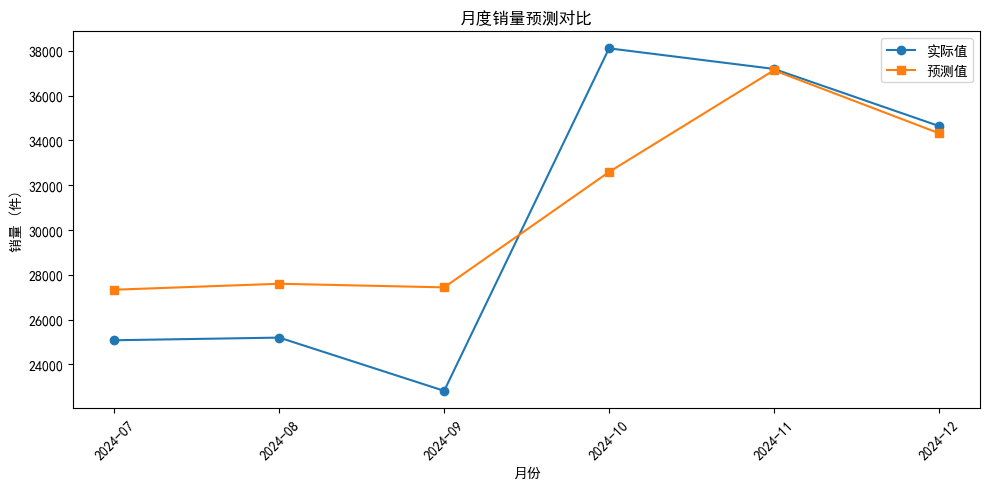

In [41]:
# 可视化对比
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# 全局设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 5))
plt.plot(test['order_month'], y_test_qty, marker='o', label='实际值')
plt.plot(test['order_month'], pred_final, marker='s', label='预测值')

plt.xticks(rotation=45)
plt.legend()
plt.title('月度销量预测对比')
plt.ylabel('销量 (件)')
plt.xlabel('月份')
plt.tight_layout()
plt.show()

### data vis 2

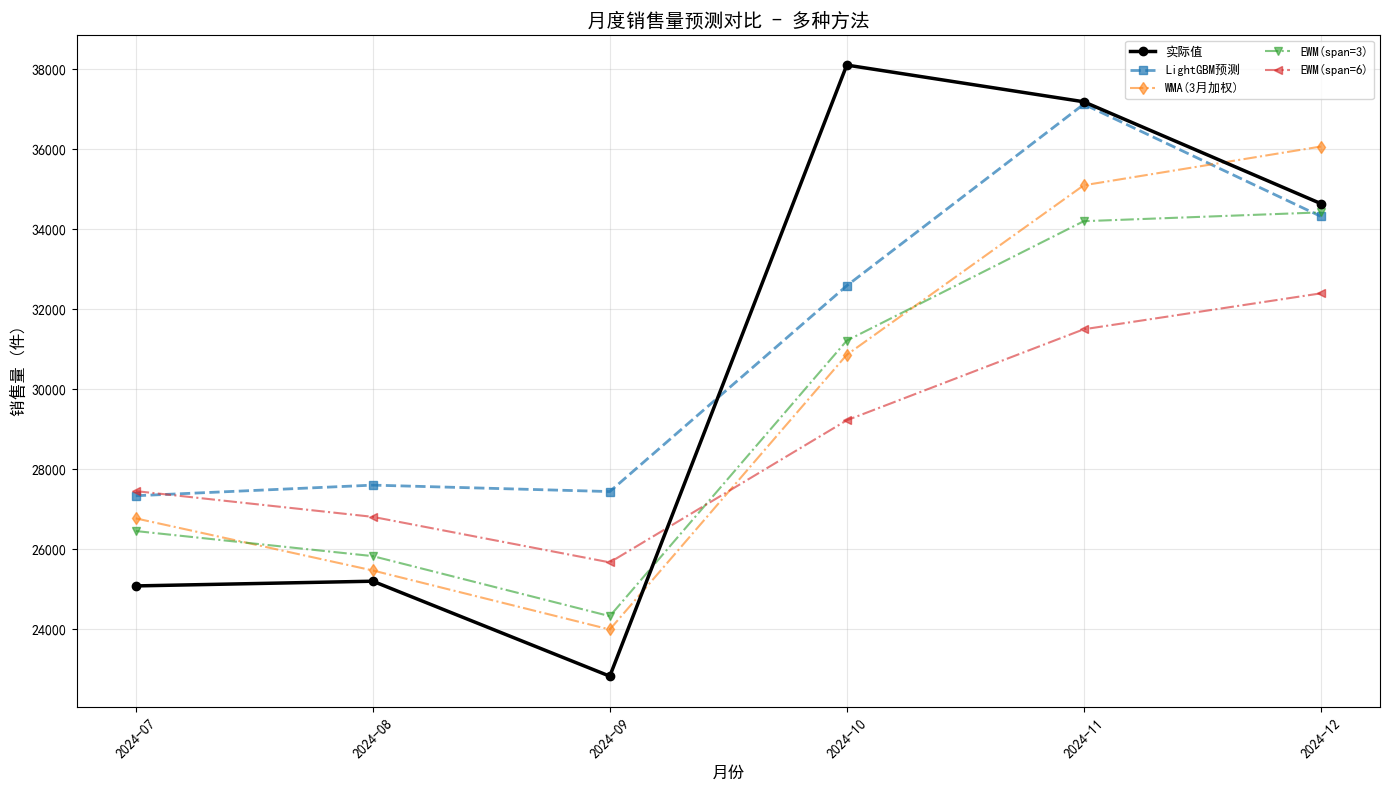

In [ ]:
# 可视化对比 - 包含多种 Baseline 方法
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# 全局设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 从 df_timeseries_features 中提取测试期间的数据
test_months = test['order_month'].values
baseline_data = df_timeseries_features[df_timeseries_features['order_month'].isin(test_months)].copy()
# 确保顺序一致
baseline_data = baseline_data.sort_values('order_month').reset_index(drop=True)

plt.figure(figsize=(14, 8))

# 实际值（粗线）
plt.plot(test['order_month'], y_test_qty, 
         marker='o', label='实际值', linewidth=2.5, color='black', zorder=10)

# LightGBM 预测（原始和校准后）
plt.plot(test['order_month'], pred_final, 
         marker='s', label='LightGBM预测', linewidth=2, alpha=0.7, linestyle='--')

# Baseline 方法组2: 加权平均
plt.plot(baseline_data['order_month'], baseline_data['wma_3'], 
         marker='d', label='WMA(3月加权)', alpha=0.6, linestyle='-.')
plt.plot(baseline_data['order_month'], baseline_data['ewm_3'], 
         marker='v', label='EWM(span=3)', alpha=0.6, linestyle='-.')
plt.plot(baseline_data['order_month'], baseline_data['ewm_6'], 
         marker='<', label='EWM(span=6)', alpha=0.6, linestyle='-.')

plt.xticks(rotation=45)
plt.legend(loc='best', ncol=2, fontsize=9)
plt.title('月度销售量预测对比 - 多种方法', fontsize=14, fontweight='bold')
plt.ylabel('销售量 (件)', fontsize=12)
plt.xlabel('月份', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [1]:
import gc

gc.collect()

31

### output the actual and predict results into a file

In [43]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

os.makedirs("output", exist_ok=True)

# 1) 长度检查：全部按销量维度校验
assert len(test) == len(y_test_qty)
assert len(test) == len(np.asarray(lgm_pred_qty_final))
assert len(test) == len(np.asarray(cat_pred_qty))
assert len(test) == len(np.asarray(pred_final))
if "prophet_pred_qty" in locals():
    assert len(test) == len(np.asarray(prophet_pred_qty))

# 2) 测试月份对应的 baseline（按销量字段）
baseline_cols = [
    "rolling_3_month_avg_quantity",
    "rolling_6_month_avg_quantity",
    "wma_3",
    "ewm_3",
    "ewm_6",
]

baseline_data_test = (
    df_timeseries_features[
        df_timeseries_features["order_month"].isin(test["order_month"].astype(str).values)
    ]
    .sort_values("order_month")
    .reset_index(drop=True)
    [["order_month"] + baseline_cols]
    .copy()
)
baseline_data_test["order_month"] = baseline_data_test["order_month"].astype(str)

# 3) 构造销量结果表
df_prediction_compare = pd.DataFrame({
    "order_month": test["order_month"].astype(str).values,
    "actual_monthly_qty": np.asarray(y_test_qty, dtype=float),

    "lightgbm_pred": np.asarray(lgm_pred_qty_final, dtype=float),
    "lightgbm_pred_calibrated": (
        np.asarray(lgm_pred_qty_calibrated, dtype=float)
        if "lgm_pred_qty_calibrated" in locals()
        else np.asarray(lgm_pred_qty_final, dtype=float)
    ),

    "catboost_pred": np.asarray(cat_pred_qty, dtype=float),
    "catboost_pred_calibrated": (
        np.asarray(cat_pred_qty_calibrated, dtype=float)
        if "cat_pred_qty_calibrated" in locals()
        else np.asarray(cat_pred_qty, dtype=float)
    ),

    "prophet_pred": (
        np.asarray(prophet_pred_qty, dtype=float)
        if "prophet_pred_qty" in locals()
        else np.asarray(np.full(len(test), np.nan), dtype=float)
    ),

    "final_pred": np.asarray(pred_final, dtype=float),
})

# 4) 合并 baseline
df_prediction_compare = df_prediction_compare.merge(
    baseline_data_test,
    on="order_month",
    how="left"
)

# 5) 计算每个模型的误差指标
df_prediction_compare["lightgbm_mae"] = (
    np.abs(df_prediction_compare["lightgbm_pred"] - df_prediction_compare["actual_monthly_qty"])
)
df_prediction_compare["lightgbm_mape"] = (
    np.abs(
        (df_prediction_compare["lightgbm_pred"] - df_prediction_compare["actual_monthly_qty"])
        / df_prediction_compare["actual_monthly_qty"].replace(0, np.nan)
    )
)

df_prediction_compare["catboost_mae"] = (
    np.abs(df_prediction_compare["catboost_pred"] - df_prediction_compare["actual_monthly_qty"])
)
df_prediction_compare["catboost_mape"] = (
    np.abs(
        (df_prediction_compare["catboost_pred"] - df_prediction_compare["actual_monthly_qty"])
        / df_prediction_compare["actual_monthly_qty"].replace(0, np.nan)
    )
)

df_prediction_compare["prophet_mae"] = (
    np.abs(df_prediction_compare["prophet_pred"] - df_prediction_compare["actual_monthly_qty"])
)
df_prediction_compare["prophet_mape"] = (
    np.abs(
        (df_prediction_compare["prophet_pred"] - df_prediction_compare["actual_monthly_qty"])
        / df_prediction_compare["actual_monthly_qty"].replace(0, np.nan)
    )
)

df_prediction_compare["final_mae"] = (
    np.abs(df_prediction_compare["final_pred"] - df_prediction_compare["actual_monthly_qty"])
)
df_prediction_compare["final_mape"] = (
    np.abs(
        (df_prediction_compare["final_pred"] - df_prediction_compare["actual_monthly_qty"])
        / df_prediction_compare["actual_monthly_qty"].replace(0, np.nan)
    )
)

# 6) 排序并查看
df_prediction_compare = df_prediction_compare.sort_values("order_month").reset_index(drop=True)
print(df_prediction_compare.head(10))

# 7) 导出 parquet
df_prediction_compare.to_parquet(
    "output/5-2-each_month_sale_qty_prediction_compare.parquet",
    index=False,
    engine="fastparquet"
)

print("已保存 parquet 文件: output/5-2-each_month_sale_qty_prediction_compare.parquet")
df_prediction_compare

  order_month  actual_monthly_qty  lightgbm_pred  lightgbm_pred_calibrated  \
0     2024-07             25080.0   30577.681572              30576.937677   
1     2024-08             25198.0   30577.681572              30576.937677   
2     2024-09             22822.0   30577.681572              30576.937677   
3     2024-10             38109.0   30577.681572              30576.937677   
4     2024-11             37191.0   33653.314930              33652.571036   
5     2024-12             34645.0   33653.314930              33652.571036   

   catboost_pred  catboost_pred_calibrated  prophet_pred    final_pred  \
0   27335.625525              29529.156822  28586.578016  27335.625525   
1   27601.593413              29795.124710  27845.808965  27601.593413   
2   27440.336763              29633.868060  24149.158485  27440.336763   
3   32589.794829              34783.326127  38168.185167  32589.794829   
4   37130.110752              39323.642050  40358.121845  37130.110752   
5   34324

,order_month,actual_monthly_qty,lightgbm_pred,lightgbm_pred_calibrated,catboost_pred,catboost_pred_calibrated,prophet_pred,final_pred,rolling_3_month_avg_quantity,rolling_6_month_avg_quantity,...,ewm_3,ewm_6,lightgbm_mae,lightgbm_mape,catboost_mae,catboost_mape,prophet_mae,prophet_mape,final_mae,final_mape
0,2024-07,25080.0,30577.681572,30576.937677,27335.625525,29529.156822,28586.578016,27335.625525,29226.666667,24362.666667,...,26452.849953,27451.584669,5497.681572,0.219206,2255.625525,0.089937,3506.578016,0.139816,2255.625525,0.089937
1,2024-08,25198.0,30577.681572,30576.937677,27601.593413,29795.124710,27845.808965,27601.593413,27804.333333,25193.333333,...,25825.424976,26807.703335,5379.681572,0.213496,2403.593413,0.095388,2647.808965,0.105080,2403.593413,0.095388
2,2024-09,22822.0,30577.681572,30576.937677,27440.336763,29633.868060,24149.158485,27440.336763,25774.666667,26113.666667,...,24323.712488,25668.930954,7755.681572,0.339834,4618.336763,0.202363,1327.158485,0.058153,4618.336763,0.202363
3,2024-10,38109.0,30577.681572,30576.937677,32589.794829,34783.326127,38168.185167,32589.794829,24366.666667,26796.666667,...,31216.356244,29223.236396,7531.318428,0.197626,5519.205171,0.144827,59.185167,0.001553,5519.205171,0.144827
4,2024-11,37191.0,33653.314930,33652.571036,37130.110752,39323.642050,40358.121845,37130.110752,28709.666667,28257.000000,...,34203.678122,31499.740283,3537.685070,0.095122,60.889248,0.001637,3167.121845,0.085158,60.889248,0.001637
5,2024-12,34645.0,33653.314930,33652.571036,34324.889551,36518.420849,38973.869069,34324.889551,32707.333333,29241.000000,...,34424.339061,32398.385916,991.685070,0.028624,320.110449,0.009240,4328.869069,0.124949,320.110449,0.009240


In [44]:
import gc
gc.collect()

65

In [37]:
# 关闭数据库连接
engine.dispose()